In [1]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install pandas matplotlib seaborn numpy 

In [3]:
!pip install scikit-learn
!pip install statsmodels

In [4]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from  sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import*

In [5]:
df = pd.read_csv("/Users/anuragpanchal/Documents/MachineLearning-/new_insurance_data.csv")

In [6]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [7]:
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [8]:
df.tail()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,170380500.5,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,201515184.8,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,223644981.3,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,252892382.6,3.0,4.006359e+09,southeast,62592.87309
1337,54.0,female,47.410,0.0,yes,63982.80926,31.0,1100328.0,261631699.3,3.0,4.117197e+09,southeast,63770.42801


In [9]:
df.shape

(1338, 13)

In [10]:
cols = df.columns

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   str    
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   str    
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   str    
 12  charges                        

In [12]:
df.isnull().sum()

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64

In [13]:
df.isnull().sum().sum()/len(df)*100

np.float64(3.8863976083707024)

In [14]:
for i in cols:
    if df[i].dtypes =='object' or df[i].dtypes=='str':
        df[i] = df[i].fillna(df[i].mode()[0])
    else:
         df[i] = df[i].fillna(df[i].mean())

In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
pd.set_option('display.float_format','{:.2f}'.format)

In [18]:
df.describe()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1338.00,1338.00,1338.00,1338.00,1338.00,1338.00,1338.00,1338.00,1338.00,1338.00
mean,39.31,30.67,1.09,33361.33,15.22,910004.70,15841791.94,1.06,369684859.70,13270.42
std,13.99,6.09,1.20,15535.31,7.45,91782.97,26653088.06,0.53,565610870.15,12110.01
min,18.00,15.96,0.00,1920.14,1.00,695430.00,29452.53,0.00,2747071.91,1121.87
25%,27.00,26.32,0.00,20947.65,9.00,847489.75,4084941.04,1.00,77550854.63,4740.29
50%,39.31,30.40,1.00,33611.29,15.00,914015.50,7500985.08,1.00,142275646.05,9382.03
75%,51.00,34.66,2.00,44978.87,20.00,971510.00,10901869.62,1.00,329871291.25,16639.91
max,64.00,53.13,5.00,77277.99,40.00,1107872.00,261631699.30,3.00,4117196637.00,63770.43


In [19]:
cols = list(cols)
len(cols)

13

In [20]:
cat_cols = ['children','NUmber_of_past_hospitalizations','sex','smoker','region']

num_cols = list(set(cols)-set(cat_cols))

In [21]:
num_cols

['charges',
 'Hospital_expenditure',
 'Claim_Amount',
 'bmi',
 'Anual_Salary',
 'past_consultations',
 'age',
 'num_of_steps']

children


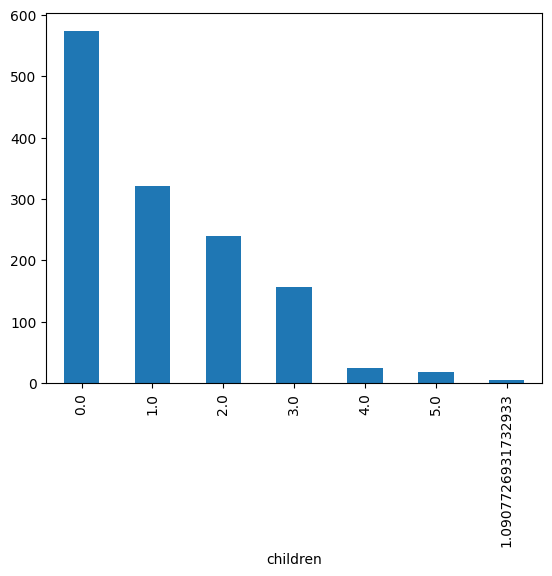

**************************************************
NUmber_of_past_hospitalizations


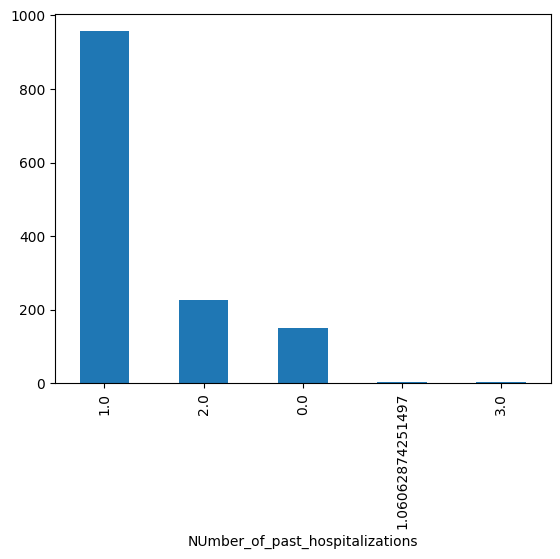

**************************************************
sex


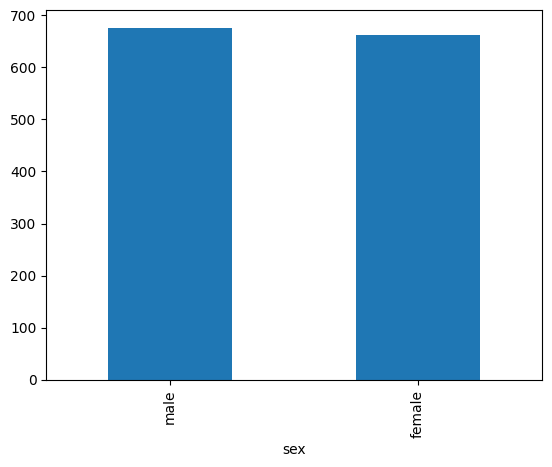

**************************************************
smoker


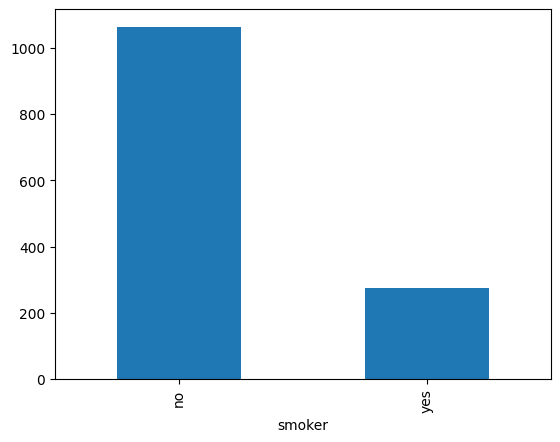

**************************************************
region


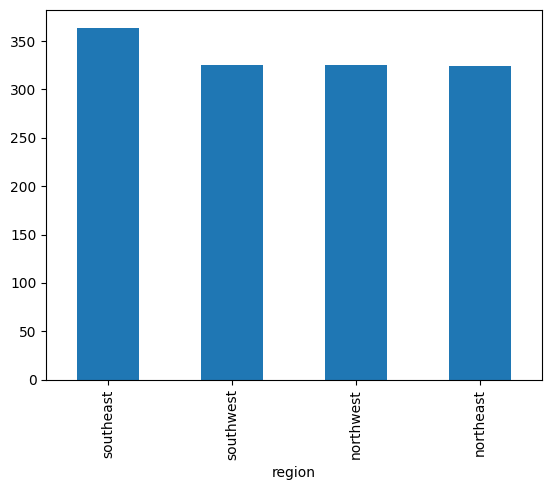

**************************************************


In [22]:
#unilateral analysis for categorical columns 

for i in cat_cols:
    print(i)
    df[i].value_counts().plot.bar()
    plt.show()
    print('*'*50)

Boxplot of charges


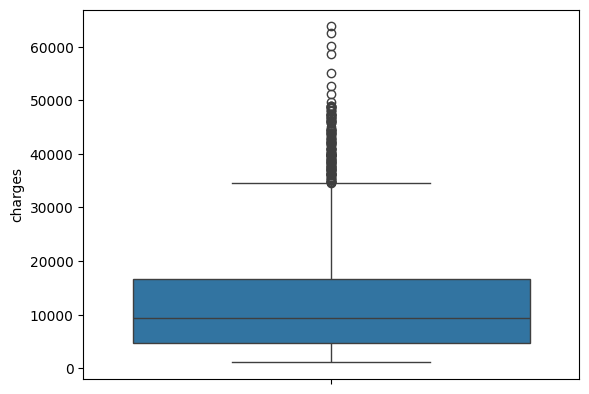

**************************************************
Histogram of charges


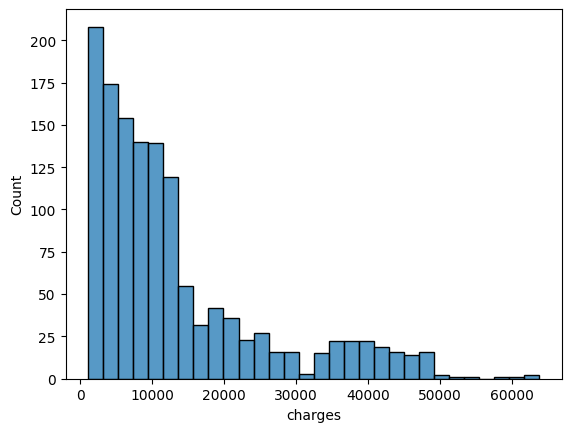

Boxplot of Hospital_expenditure


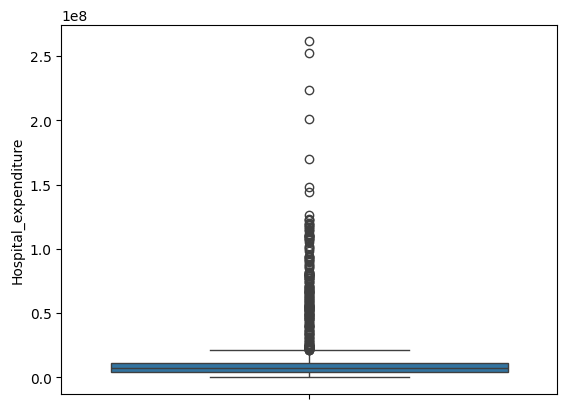

**************************************************
Histogram of Hospital_expenditure


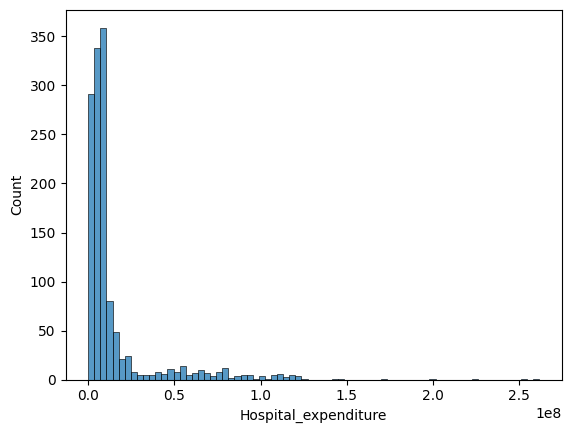

Boxplot of Claim_Amount


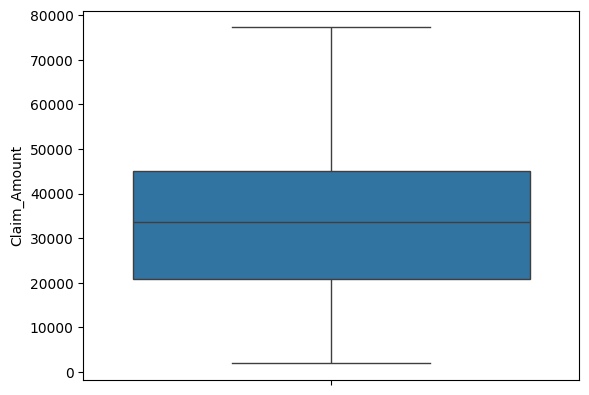

**************************************************
Histogram of Claim_Amount


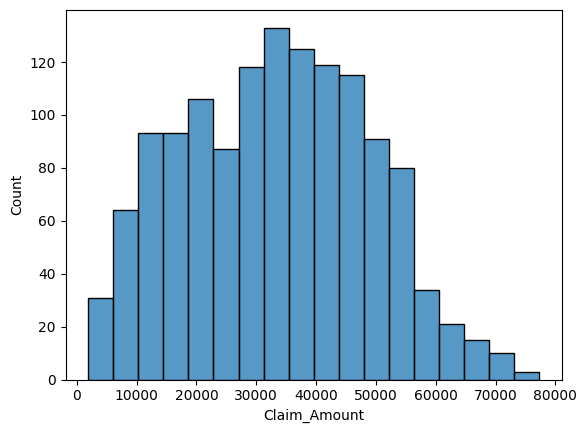

Boxplot of bmi


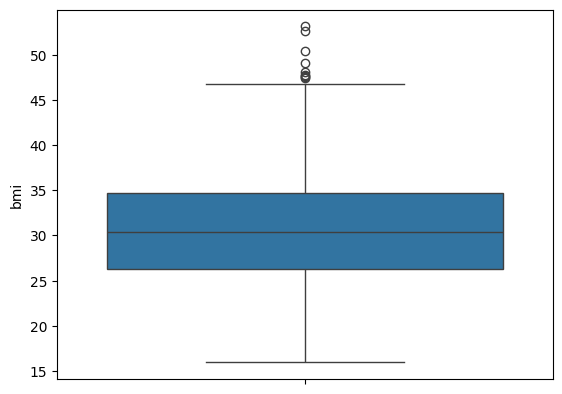

**************************************************
Histogram of bmi


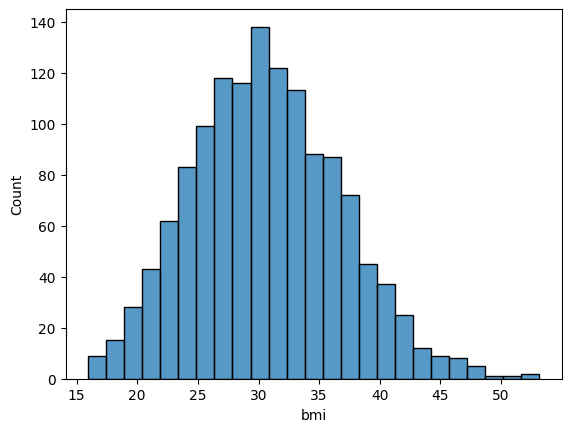

Boxplot of Anual_Salary


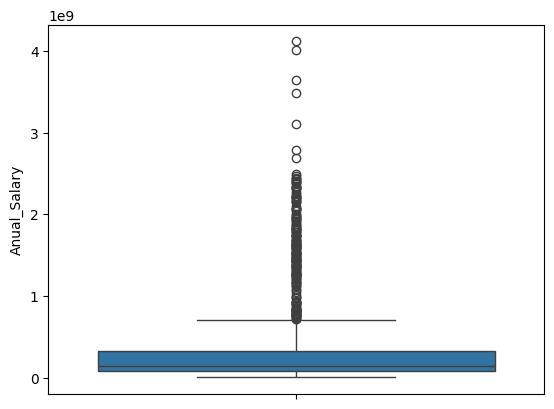

**************************************************
Histogram of Anual_Salary


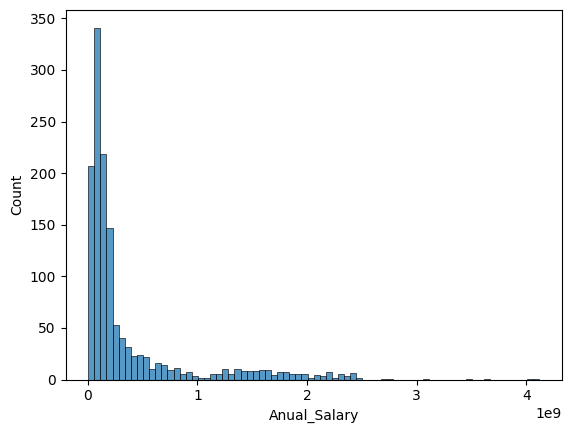

Boxplot of past_consultations


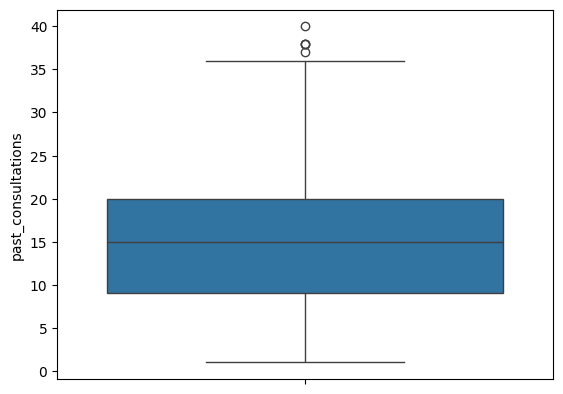

**************************************************
Histogram of past_consultations


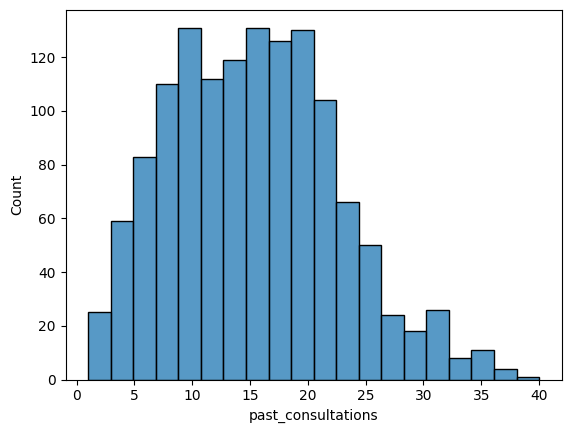

Boxplot of age


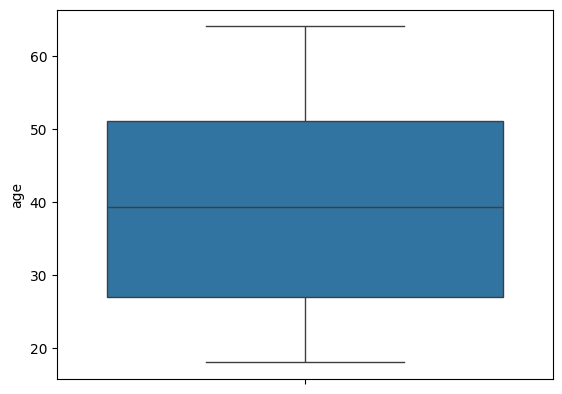

**************************************************
Histogram of age


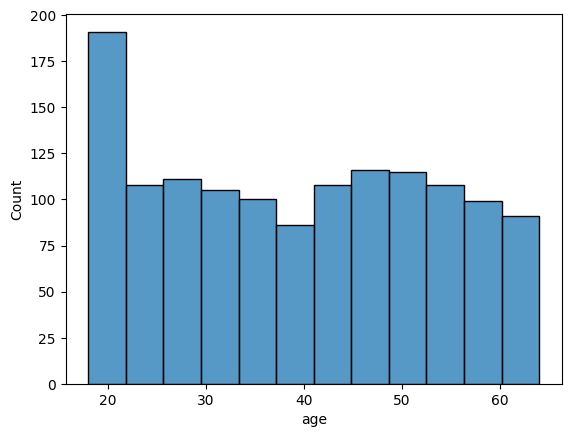

Boxplot of num_of_steps


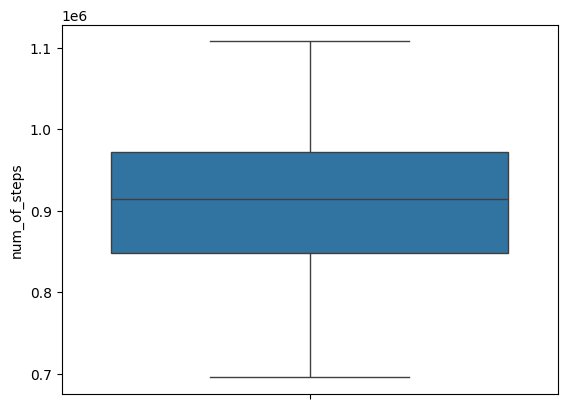

**************************************************
Histogram of num_of_steps


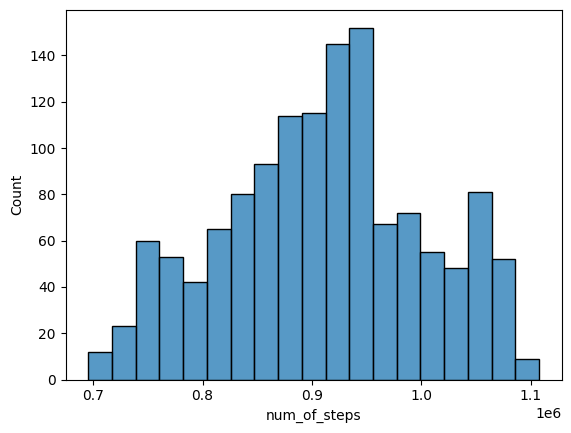

In [23]:
for i in num_cols:
    print(f"Boxplot of {i}")
    sns.boxplot(df[i],orient='v')
    plt.show()
    print('*'*50)
    print(f"Histogram of {i}")
    sns.histplot(df[i])
    plt.show()


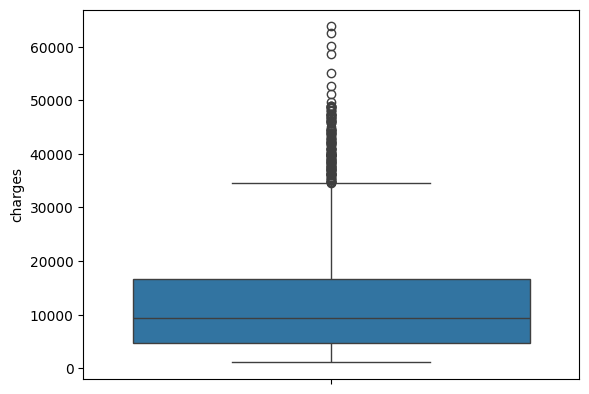

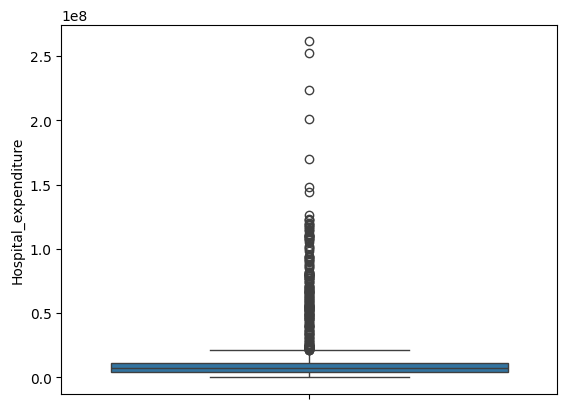

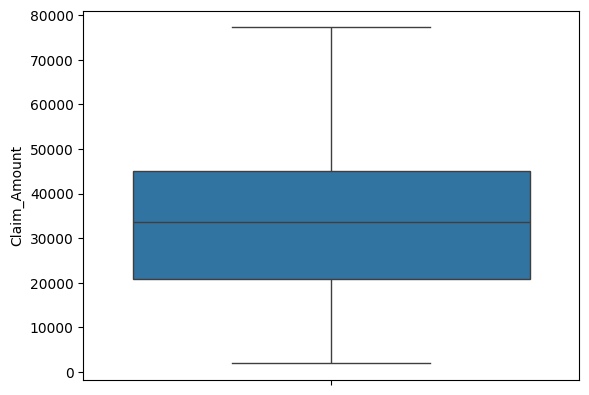

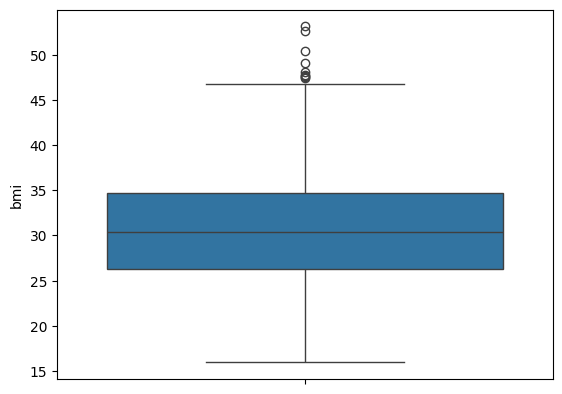

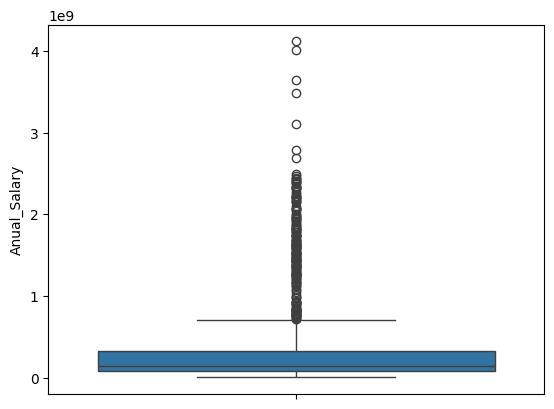

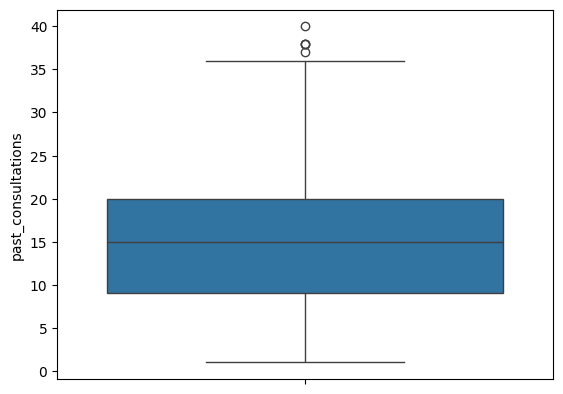

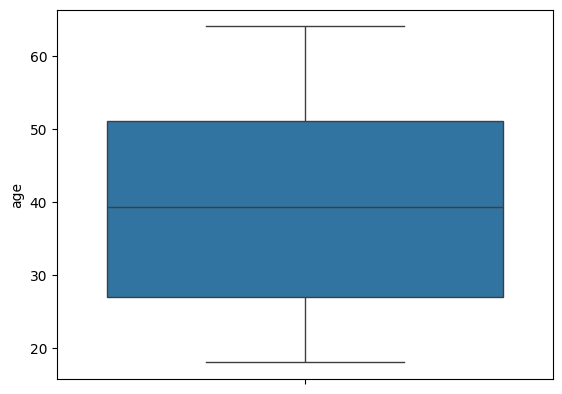

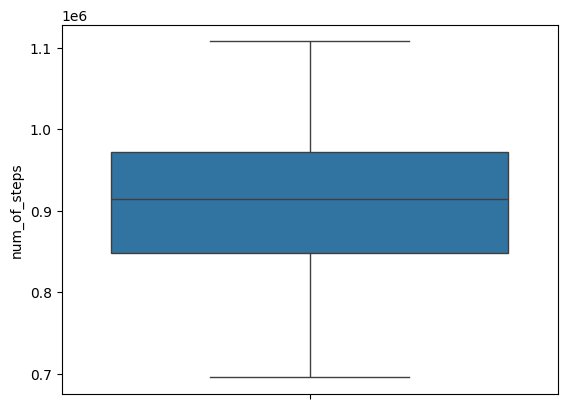

In [24]:
for i in num_cols:
    sns.boxplot(df[i])
    plt.show()

In [25]:
for i in num_cols:
    q1 = df[i].quantile(0.25)
    q2 = df[i].quantile(0.75)
    iqr = q2-q1
    lb = q1-iqr*1.5
    ub = q2+iqr*1.5
    df = df[(df[i]>=lb) & (df[i]<=ub )]



In [26]:
df.shape

(1021, 13)

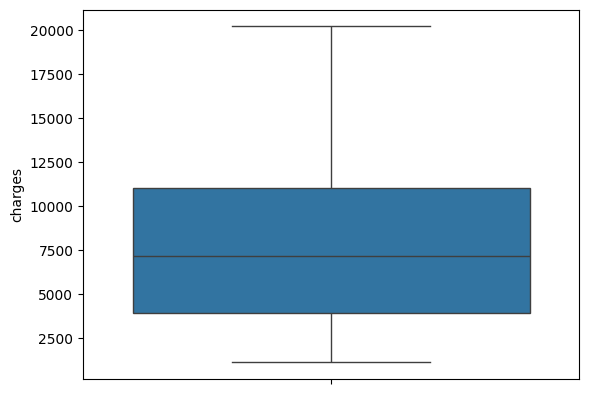

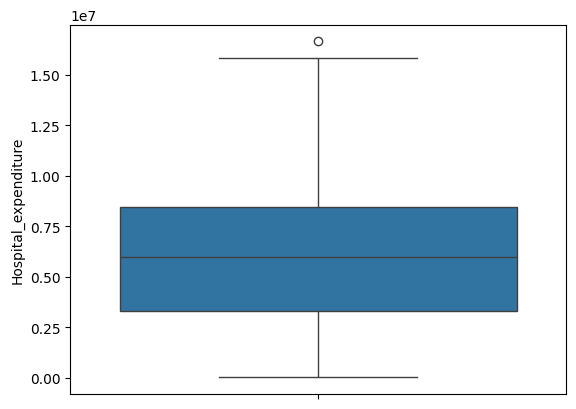

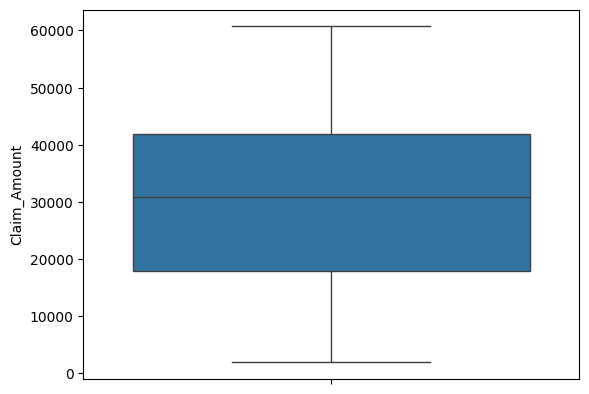

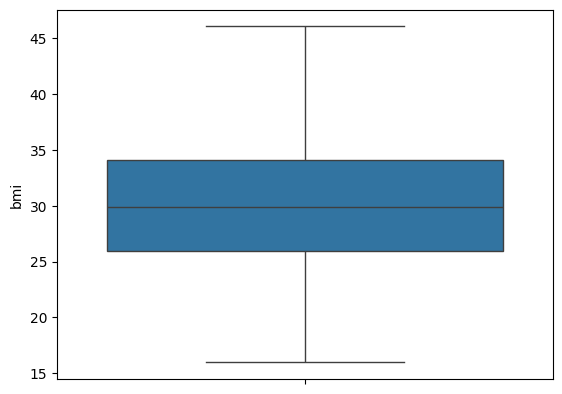

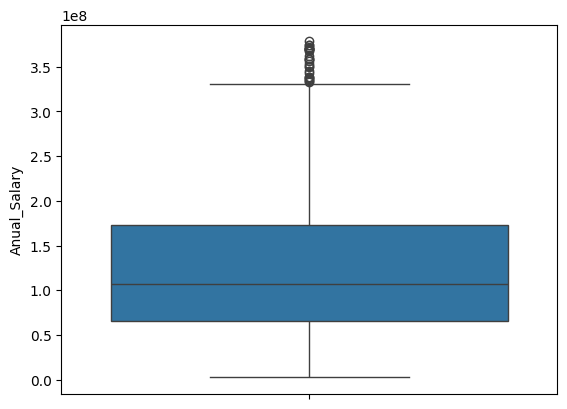

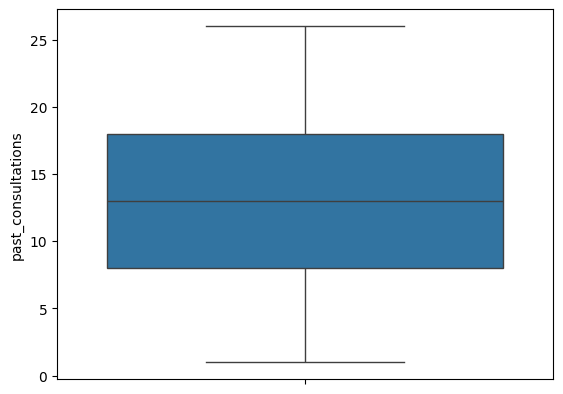

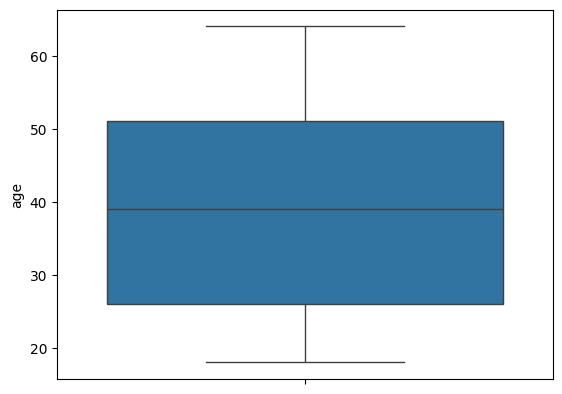

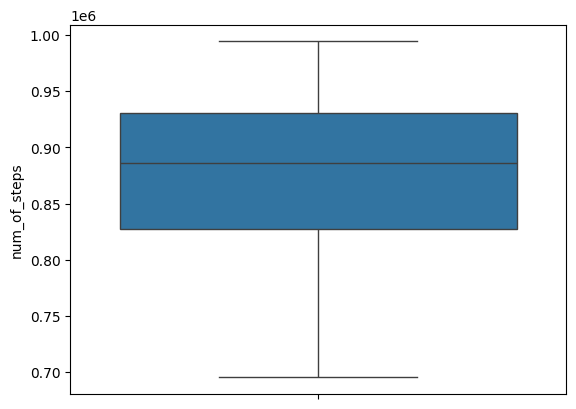

In [27]:
for i in num_cols:
    sns.boxplot(df[i])
    plt.show()

In [28]:
x = df.select_dtypes(['number'])
x.drop('charges',axis=1,inplace=True)
x

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary
0,18.00,23.21,0.00,29087.54,17.00,715428.00,4720920.99,0.00,55784970.05
1,18.00,30.14,0.00,39053.67,7.00,699157.00,4329831.68,0.00,13700885.19
2,18.00,33.33,0.00,39023.63,19.00,702341.00,6884860.77,0.00,73523107.27
3,18.00,33.66,0.00,28185.39,11.00,700250.00,4274773.55,0.00,75819679.60
4,18.00,34.10,0.00,14697.86,16.00,711584.00,3787293.92,0.00,23012320.01
...,...,...,...,...,...,...,...,...,...
1041,24.00,27.60,0.00,27184.28,9.00,980010.00,12666729.65,1.00,374322826.70
1046,29.00,27.94,1.00,51168.25,23.00,993751.00,16659821.70,1.00,371218761.20
1050,31.00,29.81,0.00,24382.58,21.00,973924.00,10289906.76,1.00,374530950.60
1062,43.00,20.05,2.00,21596.44,10.00,994419.00,10830301.14,1.00,369684859.70


In [29]:
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns
vif_data

,feature
0,age
1,bmi
2,children
3,Claim_Amount
4,past_consultations
5,num_of_steps
6,Hospital_expenditure
7,NUmber_of_past_hospitalizations
8,Anual_Salary


In [30]:
vif_data['vif'] = [variance_inflation_factor(x.values,i)  for i in range(len(x.columns)) ]

In [31]:
vif_data

,feature,vif
0,age,15.63
1,bmi,27.01
2,children,2.03
3,Claim_Amount,5.65
4,past_consultations,6.26
5,num_of_steps,62.51
6,Hospital_expenditure,5.17
7,NUmber_of_past_hospitalizations,11.99
8,Anual_Salary,5.55


In [32]:
df.drop('num_of_steps',axis=1,inplace=True)

In [33]:
x = df.select_dtypes(['number'])
x.drop('charges',axis=1,inplace=True)
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns
vif_data['vif'] = [variance_inflation_factor(x.values,i)  for i in range(len(x.columns)) ]
vif_data

,feature,vif
0,age,14.70
1,bmi,12.32
2,children,2.01
3,Claim_Amount,5.20
4,past_consultations,5.89
5,Hospital_expenditure,4.89
6,NUmber_of_past_hospitalizations,10.64
7,Anual_Salary,5.45


In [34]:
df.drop('age',axis=1,inplace=True)

In [35]:
x = df.select_dtypes(['number'])
x.drop('charges',axis=1,inplace=True)
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns
vif_data['vif'] = [variance_inflation_factor(x.values,i)  for i in range(len(x.columns)) ]
vif_data

,feature,vif
0,bmi,10.39
1,children,1.97
2,Claim_Amount,5.19
3,past_consultations,5.87
4,Hospital_expenditure,4.89
5,NUmber_of_past_hospitalizations,8.30
6,Anual_Salary,4.73


In [36]:
df.drop('bmi',axis=1,inplace=True)

In [37]:
x = df.select_dtypes(['number'])
x.drop('charges',axis=1,inplace=True)
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns
vif_data['vif'] = [variance_inflation_factor(x.values,i)  for i in range(len(x.columns)) ]
vif_data

,feature,vif
0,children,1.97
1,Claim_Amount,4.53
2,past_consultations,5.05
3,Hospital_expenditure,4.45
4,NUmber_of_past_hospitalizations,7.28
5,Anual_Salary,4.70


In [38]:
df.drop('NUmber_of_past_hospitalizations',axis=1,inplace=True)

In [39]:
x = df.select_dtypes(['number'])
x.drop('charges',axis=1,inplace=True)
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns
vif_data['vif'] = [variance_inflation_factor(x.values,i)  for i in range(len(x.columns)) ]
vif_data

,feature,vif
0,children,1.70
1,Claim_Amount,4.15
2,past_consultations,4.68
3,Hospital_expenditure,4.27
4,Anual_Salary,4.26


In [40]:
x = df.loc[:,['children','Claim_Amount','past_consultations','Hospital_expenditure','Anual_Salary']]
y = df.iloc[:,-1]

In [41]:
y

0       1121.87
1       1131.51
2       1135.94
3       1136.40
4       1137.01
         ...   
1041   18955.22
1046   19107.78
1050   19350.37
1062   19798.05
1069   20234.85
Name: charges, Length: 1021, dtype: float64

In [42]:
x

,children,Claim_Amount,past_consultations,Hospital_expenditure,Anual_Salary
0,0.00,29087.54,17.00,4720920.99,55784970.05
1,0.00,39053.67,7.00,4329831.68,13700885.19
2,0.00,39023.63,19.00,6884860.77,73523107.27
3,0.00,28185.39,11.00,4274773.55,75819679.60
4,0.00,14697.86,16.00,3787293.92,23012320.01
...,...,...,...,...,...
1041,0.00,27184.28,9.00,12666729.65,374322826.70
1046,1.00,51168.25,23.00,16659821.70,371218761.20
1050,0.00,24382.58,21.00,10289906.76,374530950.60
1062,2.00,21596.44,10.00,10830301.14,369684859.70


In [43]:
x_train ,x_test,y_train,y_test = train_test_split(x,y , test_size=0.2,random_state=42)

In [44]:
x_train.shape,x_test.shape

((816, 5), (205, 5))

In [45]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
pred = model.predict(x_test)

In [47]:
error_pred = pd.DataFrame(columns=['Actual_Data','Prediction Data'])

In [48]:
error_pred['Actual_Data'] = y_test
error_pred['Prediction Data'] = pred

In [49]:
error_pred['error'] = error_pred['Prediction Data']-error_pred['Actual_Data']

In [50]:
error_pred

,Actual_Data,Prediction Data,error
528,7323.73,7643.37,319.63
608,8522.00,10550.26,2028.25
531,7345.08,8809.20,1464.11
32,1629.83,4866.06,3236.22
622,8605.36,6995.11,-1610.25
...,...,...,...
453,6356.27,5356.87,-999.40
791,11299.34,10462.86,-836.48
599,8410.05,6364.33,-2045.72
920,13393.76,15001.49,1607.73


In [51]:
r2 = r2_score(y_test,pred)

In [52]:
r2

0.843484074855058

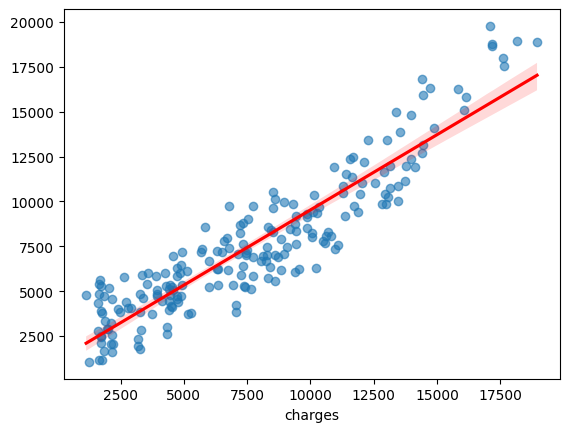

In [58]:
plt.Figure(figsize=(12,4))
sns.regplot(x=y_test,y=pred,scatter_kws={'alpha':0.6},line_kws={'color':'red'})
plt.show()